# 06 Test Set Evaluation

## Purpose

This notebook runs held-out test evaluation for one completed training run.

## Inputs

- `best_model/` from one experiment folder in `MyDrive/ProjectRoot/checkpoints/`
- `test_dataset.pt` from the matching tokenizer setting in `MyDrive/ProjectRoot/tokenized_datasets/`
- `MyDrive/ProjectRoot/registry/run_index.csv`

## Outputs

- summary test metrics
- per-class metrics
- ROC plot and ROC summary table
- precision-recall plot and PR summary table
- qualitative probe results
- run index updates

## Notes to myself

I'm using the test split here because this is where I want the real comparison between tokenizers and model runs to happen. The validation split is only for training diagnostics. I also don't think the evaluation is fully settled yet, so this notebook is meant to be a structured starting point rather than the final word on how every metric should be interpreted.



## Setup note

Same Colab pattern as the tokenizer, preprocessing, training, and validation notebooks.

- code and notebooks stay in GitHub
- test outputs stay in Drive
- Colab pulls the repo at the start so the latest evaluation helpers are available
- before running the evaluation cells, I only need to pick the tokenizer family and experiment name in the config cell

I'm keeping that split because the models, plots, and result tables will add up quickly, and I want the repo to stay readable for someone else opening it later.



In [1]:
# ==============================================================================
# 0. SET UP THE COLAB ENVIRONMENT
# ==============================================================================
import os
import sys

from google.colab import drive

# Mount Google Drive so the notebook can read data files and save outputs.
drive.mount('/content/drive')

# Clone the public GitHub repository into the Colab runtime.
GITHUB_OWNER = 'hb791-dev'
REPO_NAME = 'glycan-roberta'
REPO_URL = f'https://github.com/{GITHUB_OWNER}/{REPO_NAME}.git'
REPO_DIR = f'/content/{REPO_NAME}'

if not os.path.exists(REPO_DIR):
    print('Cloning repository...')
    !git clone -q {REPO_URL} {REPO_DIR}
else:
    print('Repository already exists. Pulling latest changes...')

%cd {REPO_DIR}
!git pull origin main --no-edit -q

# Add the repo to the Python path so src/ imports work across notebooks.
if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

print('Colab environment ready.')
print(f'Repo directory: {REPO_DIR}')



Mounted at /content/drive
Cloning repository...
/content/glycan-roberta
Colab environment ready.
Repo directory: /content/glycan-roberta


## Pick the run

This is the only place I should need to change things for a new test evaluation. I want the tokenizer family and experiment name to stay aligned with the saved best model and the matching tokenized test set so I don't accidentally evaluate the wrong model against the wrong data.

Supported families in this notebook: `byte_bpe`, `glyberta`, `manual`, `hybrid_char_bpe`, `linkage_block`, `donor_bound`, and `semi_atomic`.

The tokenizer setting label is selected automatically from a small mapping so the newer rule-based tokenizers follow the same workflow as the original families.



In [2]:
# ==============================================================================
# 1. TEST EVALUATION CONFIG
# ==============================================================================
TOKENIZER_SETTINGS = {
    'byte_bpe': 'v300_m2',
    'glyberta': 'v1_train_only',
    'manual': 'v1_train_only',
    'hybrid_char_bpe': 'v70_m2',
    'linkage_block': 'v1_train_only',
    'donor_bound': 'v1_train_only',
    'semi_atomic': 'v1_train_only',
}

TOKENIZER_FAMILY = 'byte_bpe'
if TOKENIZER_FAMILY not in TOKENIZER_SETTINGS:
    raise ValueError(f'Unsupported tokenizer family: {TOKENIZER_FAMILY}')
SETTING_LABEL = TOKENIZER_SETTINGS[TOKENIZER_FAMILY]
EXPERIMENT_NAME = 'mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20'

MLM_PROBABILITY = 0.15
MASK_SEED = 42
BATCH_SIZE = 16



## Load the helper functions

I'm keeping most of the evaluation logic in `src/test_evaluation.py` so this notebook doesn't turn into a giant wall of code. The notebook should mostly be for routing, running, checking outputs, and saving results. That also makes it easier to revise the metric definitions later if my understanding changes or if my professor wants them framed a little differently.



In [3]:
# ==============================================================================
# 2. IMPORTS
# ==============================================================================
import json
import os
import sys

import pandas as pd
import torch
from IPython.display import display

sys.path.append(REPO_DIR)

from src.run_index import upsert_run_record
from src.test_evaluation import (
    build_masked_test_dataset,
    build_masking_summary,
    build_test_summary_row,
    compute_per_class_metrics,
    compute_summary_classification_metrics,
    compute_topk_metrics,
    get_core_probe_cases,
    get_tokenizer_specific_roc_pr_tokens,
    load_test_artifacts,
    plot_pr_for_selected_classes,
    plot_top1_correctness_roc_curves,
    plot_top1_correctness_pr_curves,
    plot_roc_for_selected_classes,
    run_mlm_test_predictions,
    run_structured_qualitative_probe,
)





## Build paths

This cell wires together the model folder, the tokenized test set, the results folder, and the run index. I want all of those paths built from the same tokenizer family and experiment name so the outputs stay organized automatically. If I end up evaluating a lot of runs, this should make it much harder to mix up which artifacts came from which tokenizer and training configuration.



In [4]:
# ==============================================================================
# 3. PATHS
# ==============================================================================
PROJECT_ROOT = '/content/drive/MyDrive/ProjectRoot'
RUN_INDEX_PATH = os.path.join(PROJECT_ROOT, 'registry', 'run_index.csv')

BEST_MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    'checkpoints',
    TOKENIZER_FAMILY,
    EXPERIMENT_NAME,
    'best_model',
)

TEST_DATASET_PATH = os.path.join(
    PROJECT_ROOT,
    'tokenized_datasets',
    TOKENIZER_FAMILY,
    SETTING_LABEL,
    'test_dataset.pt',
)

RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    'results',
    'test_evaluation',
    TOKENIZER_FAMILY,
    EXPERIMENT_NAME,
)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEST_SUMMARY_JSON_PATH = os.path.join(RESULTS_DIR, 'test_summary.json')
TEST_SUMMARY_ROW_PATH = os.path.join(RESULTS_DIR, 'test_summary_row.csv')
MASKING_SUMMARY_PATH = os.path.join(RESULTS_DIR, 'masking_summary.csv')
PER_CLASS_METRICS_PATH = os.path.join(RESULTS_DIR, 'per_class_metrics.csv')
ROC_PLOT_PATH = os.path.join(RESULTS_DIR, 'roc_curves.png')
ROC_SUMMARY_PATH = os.path.join(RESULTS_DIR, 'roc_auc_summary.csv')
PR_PLOT_PATH = os.path.join(RESULTS_DIR, 'pr_curves.png')
PR_SUMMARY_PATH = os.path.join(RESULTS_DIR, 'pr_auc_summary.csv')
TOP1_ROC_PLOT_PATH = os.path.join(RESULTS_DIR, 'top1_correctness_roc_curves.png')
TOP1_ROC_SUMMARY_PATH = os.path.join(RESULTS_DIR, 'top1_correctness_roc_summary.csv')
TOP1_ROC_PER_CLASS_PATH = os.path.join(RESULTS_DIR, 'top1_correctness_roc_per_class.csv')
TOP1_PR_PLOT_PATH = os.path.join(RESULTS_DIR, 'top1_correctness_pr_curves.png')
TOP1_PR_SUMMARY_PATH = os.path.join(RESULTS_DIR, 'top1_correctness_pr_summary.csv')
TOP1_PR_PER_CLASS_PATH = os.path.join(RESULTS_DIR, 'top1_correctness_pr_per_class.csv')
QUALITATIVE_PROBE_PATH = os.path.join(RESULTS_DIR, 'qualitative_probe_results.csv')

print(f'Best model dir: {BEST_MODEL_DIR}')
print(f'Test dataset path: {TEST_DATASET_PATH}')
print(f'Results dir: {RESULTS_DIR}')





Best model dir: /content/drive/MyDrive/ProjectRoot/checkpoints/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/best_model
Test dataset path: /content/drive/MyDrive/ProjectRoot/tokenized_datasets/byte_bpe/v300_m2/test_dataset.pt
Results dir: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20


## Quick safety check

I want this to fail early if `best_model/` or the saved test dataset is missing. That is better than waiting through setup and then realizing the run folder wasn't complete. Since notebook 4 had a few save/finalization issues while I was building this workflow, I don't want to assume every training folder is ready until this check passes.



In [5]:
# ==============================================================================
# 4. CHECK INPUT ARTIFACTS
# ==============================================================================
required_paths = [BEST_MODEL_DIR, TEST_DATASET_PATH]
for path in required_paths:
    if not os.path.exists(path):
        raise FileNotFoundError(f'Missing required path: {path}')

print('Required artifacts found.')



Required artifacts found.


## Load the trained model and test dataset

At this point I'm loading exactly the saved best model I want to evaluate, not a checkpoint I happened to stop on. This matters because the test notebook is supposed to reflect the run I would actually report, not just one intermediate point from training history.



In [6]:
# ==============================================================================
# 5. LOAD MODEL, TOKENIZER, AND TEST DATA
# ==============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

tokenizer, model, test_dataset = load_test_artifacts(
    model_dir=BEST_MODEL_DIR,
    test_dataset_path=TEST_DATASET_PATH,
    device=device,
)

print(f'Loaded tokenizer from: {BEST_MODEL_DIR}')
print(f'Loaded test dataset with {len(test_dataset)} sequences')



Using device: cpu


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

Loaded tokenizer from: /content/drive/MyDrive/ProjectRoot/checkpoints/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/best_model
Loaded test dataset with 2182 sequences


## Build a fixed masked test set

I want masking on test to be deterministic so the evaluation is reproducible. If I rerun this notebook with the same seed and same model, I should be testing against the same masked positions. That way differences between runs should come from the tokenizer or model, not from a new random masking pattern each time.



In [7]:
# ==============================================================================
# 6. BUILD DETERMINISTIC MASKED TEST SET
# ==============================================================================
masked_dataset_dict = build_masked_test_dataset(
    test_dataset=test_dataset,
    tokenizer=tokenizer,
    mlm_probability=MLM_PROBABILITY,
    seed=MASK_SEED,
)

masking_summary = build_masking_summary(
    masked_dataset_dict=masked_dataset_dict,
    mlm_probability=MLM_PROBABILITY,
    mask_seed=MASK_SEED,
)

display(masking_summary)
masking_summary.to_csv(MASKING_SUMMARY_PATH, index=False)

print(f'Masking summary saved to: {MASKING_SUMMARY_PATH}')



,metric,value
0,test_sequences,2182.00
1,masked_positions,11225.00
2,mlm_probability,0.15
3,mask_seed,42.00


Masking summary saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/masking_summary.csv


## Run prediction over masked positions

This is the step that actually turns the masked test set into model outputs. I'm keeping both token-level outputs and sequence-level flags because I want top-1 and top-3 summaries at both levels. Token-level results tell me how often individual masked positions are recovered, while sequence-level flags give a stricter view of whether the model recovered every masked token in a sequence.



In [8]:
# ==============================================================================
# 7. RUN TEST PREDICTIONS
# ==============================================================================
y_true, y_pred, y_probs, sequence_top1_flags, sequence_top3_flags = run_mlm_test_predictions(
    model=model,
    masked_dataset_dict=masked_dataset_dict,
    batch_size=BATCH_SIZE,
    device=device,
)

prediction_summary = pd.DataFrame(
    {
        'metric': [
            'masked_token_predictions',
            'evaluated_sequences',
        ],
        'value': [
            len(y_true),
            len(sequence_top1_flags),
        ],
    }
)

display(prediction_summary)



,metric,value
0,masked_token_predictions,11225
1,evaluated_sequences,2182


### Interpreting the evaluation outputs and summary metrics

After running the model on the masked test set, the evaluation code stores three main outputs for every masked position.

`y_true` is the true token ID at each masked position. In other words, this is the correct answer the model is supposed to recover.

`y_pred` is the model's top-1 predicted token ID at each masked position. This is the single token with the highest predicted score.

`y_probs` is the full probability vector at each masked position. For each masked token, it contains the model's predicted probabilities across the full vocabulary, not just the top prediction.

These outputs are then used to compute the summary metrics.

In the per-class metrics table, `support` means the number of times a token appears as the true masked target in the test set. For example, if `GlcNAc` has support 332, that means 332 entries in `y_true` are `GlcNAc`. If `Glc` has support 57, then only 57 masked positions had `Glc` as the correct answer.

The `macro_` metrics average per-class precision, recall, and F1 equally across token classes. A token with support 57 contributes just as much to the final average as a token with support 2303. This makes the macro metrics useful for judging whether performance is balanced across both common and rare tokens.

The `weighted_` metrics use the same per-class precision, recall, and F1 values, but weight each class by its support. This means classes that appear more often in `y_true` have more influence on the final score.

This distinction matters because a model can perform very well on common tokens and less well on rare tokens at the same time. In that case, the `weighted_` metrics may still look strong, while the `macro_` metrics will be lower. A noticeable gap between macro and weighted scores therefore suggests that performance is not equally strong across all token classes, and that lower-support tokens may be harder for the model to predict reliably.




## Save the main summary metrics

This is the compact metrics block I will actually compare later. Right now I'm treating it as the main summary view of held-out test performance, but I still think the interpretation will take some iteration.

The top-1 and top-3 metrics tell me how often the true masked token was recovered exactly or at least included among the top guesses. Precision and recall are being used here in the one-vs-rest masked-token classification sense, so they summarize how cleanly the model separates token classes on the held-out masked positions. Sensitivity is effectively the same recall summary, and specificity is there to say something about false-positive behavior from the other side.

I don't think any one of these numbers should be over-read by itself. My hope is that together they give a more grounded picture than loss alone.



In [9]:
# ==============================================================================
# 8. COMPUTE SUMMARY METRICS
# ==============================================================================
topk_metrics = compute_topk_metrics(
    y_true=y_true,
    y_probs=y_probs,
    y_pred=y_pred,
    sequence_top1_flags=sequence_top1_flags,
    sequence_top3_flags=sequence_top3_flags,
)

classification_metrics = compute_summary_classification_metrics(
    y_true=y_true,
    y_pred=y_pred,
)

all_metrics = {}
all_metrics.update(topk_metrics)
all_metrics.update(classification_metrics)

summary_df = pd.DataFrame(
    {
        'metric': list(all_metrics.keys()),
        'value': list(all_metrics.values()),
    }
)

display(summary_df)

with open(TEST_SUMMARY_JSON_PATH, 'w', encoding='utf-8') as file:
    json.dump(all_metrics, file, indent=2)

test_summary_row = build_test_summary_row(
    tokenizer_family=TOKENIZER_FAMILY,
    setting_label=SETTING_LABEL,
    experiment_name=EXPERIMENT_NAME,
    metrics_dict=all_metrics,
)
test_summary_row.to_csv(TEST_SUMMARY_ROW_PATH, index=False)

print(f'Test summary JSON saved to: {TEST_SUMMARY_JSON_PATH}')
print(f'Test summary row saved to: {TEST_SUMMARY_ROW_PATH}')



,metric,value
0,token_top1_accuracy,0.957595
1,token_top3_accuracy,0.994477
2,sequence_top1_accuracy,0.810724
3,sequence_top3_accuracy,0.972044
4,macro_precision,0.893690
5,macro_recall,0.852668
6,macro_f1,0.857149
7,macro_sensitivity,0.852668
8,macro_specificity,0.999158
9,weighted_precision,0.957724


Test summary JSON saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/test_summary.json
Test summary row saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/test_summary_row.csv


## Look at per-class behavior

The summary metrics are useful, but they can hide which tokens the model is actually good or bad at. This table is where I can start seeing whether certain residues or linkage-related tokens are being handled unevenly.

I especially want this because the vocabularies are different across tokenizers. A model might look okay on the overall summary while still performing badly on a token class that is biologically important.



In [10]:
# ==============================================================================
# 9. PER-CLASS METRICS
# ==============================================================================
per_class_metrics = compute_per_class_metrics(
    y_true=y_true,
    y_pred=y_pred,
    tokenizer=tokenizer,
)

display(per_class_metrics.head(20))
per_class_metrics.to_csv(PER_CLASS_METRICS_PATH, index=False)

print(f'Per-class metrics saved to: {PER_CLASS_METRICS_PATH}')



,token_id,token,precision,recall,f1,support
4,21,1,0.996963,0.997829,0.997396,2303
3,17,-,1.000000,1.000000,1.000000,1796
11,35,?,0.994261,0.997122,0.995690,695
7,24,4,0.929972,0.976471,0.952654,680
27,271,GlcNAcb,0.904924,0.926957,0.915808,575
6,23,3,0.951163,0.887202,0.918070,461
5,22,2,0.964365,0.951648,0.957965,455
1,13,),1.000000,0.995000,0.997494,400
28,272,Galb,0.938424,0.971939,0.954887,392
0,12,(,1.000000,1.000000,1.000000,377


Per-class metrics saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/per_class_metrics.csv


## All-token top-1 correctness ROC curves

This uses the same correct-versus-incorrect top-1 setup as the paired PR section below. Within each true token class, a masked position counts as positive when the model's top-1 guess is correct and negative when it is not, and the score is again the confidence of that top-1 guess.

I want macro and weighted versions here too. The macro ROC gives each true token class equal influence, while the weighted ROC lets high-support classes contribute more. Unlike the PR case, ROC does not need the same monotonic-envelope cleanup because the per-class ROC traces are already monotone by construction.



In [ ]:
# ==============================================================================
# 10. ALL-TOKEN TOP-1 CORRECTNESS ROC CURVES
# ==============================================================================
top1_roc_summary, top1_roc_per_class = plot_top1_correctness_roc_curves(
    y_true=y_true,
    y_pred=y_pred,
    y_probs=y_probs,
    tokenizer=tokenizer,
    save_path=TOP1_ROC_PLOT_PATH,
)

display(top1_roc_summary)
display(top1_roc_per_class.head(20))

top1_roc_summary.to_csv(TOP1_ROC_SUMMARY_PATH, index=False)
top1_roc_per_class.to_csv(TOP1_ROC_PER_CLASS_PATH, index=False)

print(f'Top-1 correctness ROC plot saved to: {TOP1_ROC_PLOT_PATH}')
print(f'Top-1 correctness ROC summary saved to: {TOP1_ROC_SUMMARY_PATH}')
print(f'Top-1 correctness per-class summary saved to: {TOP1_ROC_PER_CLASS_PATH}')



## All-token top-1 correctness PR curves

This is a different precision-recall question from the tokenizer-specific one-vs-rest curves below. Here, each masked position is labeled `correct` if the model's top-1 guess matches the true token and `incorrect` otherwise, and the score is the confidence assigned to that top-1 guess.

I want both macro and weighted versions of this curve. The macro view gives each true token class equal influence, while the weighted view lets high-support classes contribute more. I am also forcing each per-class curve into a monotonic precision envelope before averaging so the aggregate curves behave like standard interpolated PR curves instead of jagged threshold traces.




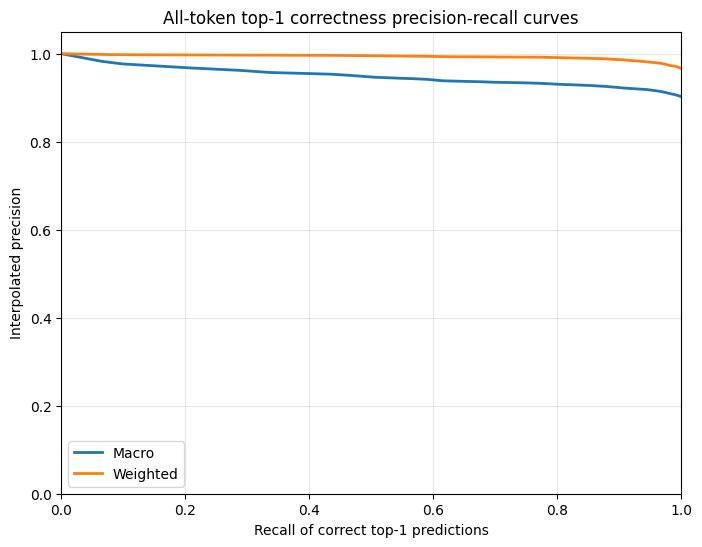

,aggregation,average_precision,num_classes,num_examples
0,macro,0.931566,52,11225
1,weighted,0.992216,52,11225


,token_id,token,support,correct_count,incorrect_count,top1_accuracy,average_precision
4,21,1,2303,2298,5,0.997829,0.999999
3,17,-,1796,1796,0,1.000000,1.000000
11,35,?,695,693,2,0.997122,0.999998
7,24,4,680,664,16,0.976471,0.998944
27,271,GlcNAcb,575,533,42,0.926957,0.996226
6,23,3,461,409,52,0.887202,0.984879
5,22,2,455,433,22,0.951648,0.998851
1,13,),400,398,2,0.995000,0.999962
28,272,Galb,392,381,11,0.971939,0.999174
0,12,(,377,377,0,1.000000,1.000000


Top-1 correctness PR plot saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/top1_correctness_pr_curves.png
Top-1 correctness PR summary saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/top1_correctness_pr_summary.csv
Top-1 correctness per-class summary saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/top1_correctness_pr_per_class.csv


In [11]:
# ==============================================================================
# 11. ALL-TOKEN TOP-1 CORRECTNESS PRECISION-RECALL CURVES
# ==============================================================================
top1_pr_summary, top1_pr_per_class = plot_top1_correctness_pr_curves(
    y_true=y_true,
    y_pred=y_pred,
    y_probs=y_probs,
    tokenizer=tokenizer,
    save_path=TOP1_PR_PLOT_PATH,
)

display(top1_pr_summary)
display(top1_pr_per_class.head(20))

top1_pr_summary.to_csv(TOP1_PR_SUMMARY_PATH, index=False)
top1_pr_per_class.to_csv(TOP1_PR_PER_CLASS_PATH, index=False)

print(f'Top-1 correctness PR plot saved to: {TOP1_PR_PLOT_PATH}')
print(f'Top-1 correctness PR summary saved to: {TOP1_PR_SUMMARY_PATH}')
print(f'Top-1 correctness per-class summary saved to: {TOP1_PR_PER_CLASS_PATH}')





## ROC curves

These token choices are tokenizer-specific on purpose. I don't want to pretend the vocabularies are interchangeable, so this plot should only use token classes that make sense for the tokenizer I am evaluating.

For the manual and GlyBERTa-style tokenizers, that usually means residue and linkage tokens directly. For linkage-block tokenization, the interpretable unit is the whole donor-plus-linkage block. For donor-bound tokenization, some of the most meaningful tokens are donor units and acceptor-position tokens separately. For semi-atomic tokenization, residue and anomer/donor tokens can be evaluated independently. For hybrid and byte BPE, some useful units are merged motifs or fragmented approximations of the same biology.

I'm using ROC here because my professor asked for it, but I don't think it should be treated as equally informative for every token class.



Selected ROC/PR tokens:
['GlcNAc', 'Gal', 'Man', 'Fuc', 'NeuAc', 'GalNAc', 'Glc', 'GlcA', 'Galb', 'GlcNAcb']


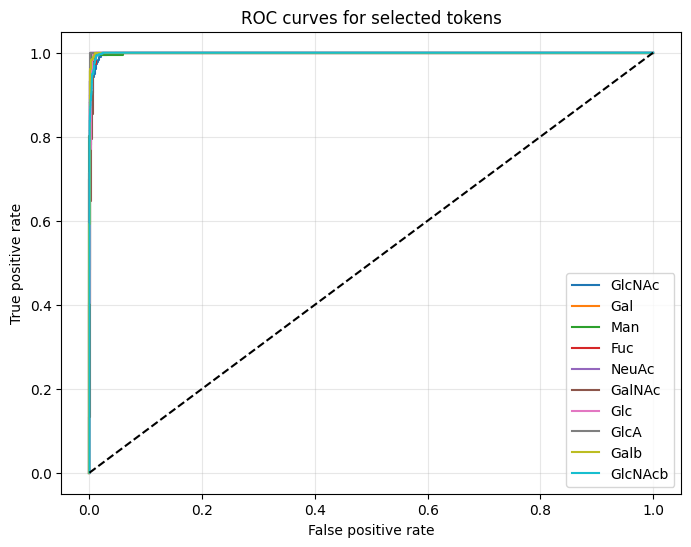

,token,auc
0,GlcNAc,0.998360
1,Gal,0.999219
2,Man,0.999429
3,Fuc,0.999523
4,NeuAc,0.999793
5,GalNAc,0.998202
6,Glc,0.999015
7,GlcA,0.999822
8,Galb,0.999643
9,GlcNAcb,0.999120


ROC plot saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/roc_curves.png
ROC summary saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/roc_auc_summary.csv


In [12]:
# ==============================================================================
# 12. ROC CURVES FOR TOKENIZER-SPECIFIC TOKENS
# ==============================================================================
roc_pr_tokens = get_tokenizer_specific_roc_pr_tokens()
selected_tokens = roc_pr_tokens[TOKENIZER_FAMILY]

print('Selected ROC/PR tokens:')
print(selected_tokens)

roc_summary = plot_roc_for_selected_classes(
    y_true=y_true,
    y_probs=y_probs,
    tokenizer=tokenizer,
    selected_tokens=selected_tokens,
    save_path=ROC_PLOT_PATH,
)

display(roc_summary)
roc_summary.to_csv(ROC_SUMMARY_PATH, index=False)

print(f'ROC plot saved to: {ROC_PLOT_PATH}')
print(f'ROC summary saved to: {ROC_SUMMARY_PATH}')




## Precision-recall curves

I'm pairing this with ROC because class balance can be weird here. Some tokens will be much rarer than others, so a precision-recall view may end up being more honest about what the model is doing on those selected classes.

I don't fully know yet whether ROC or PR will end up being more useful in the writeup, so for now I want both saved and easy to compare.



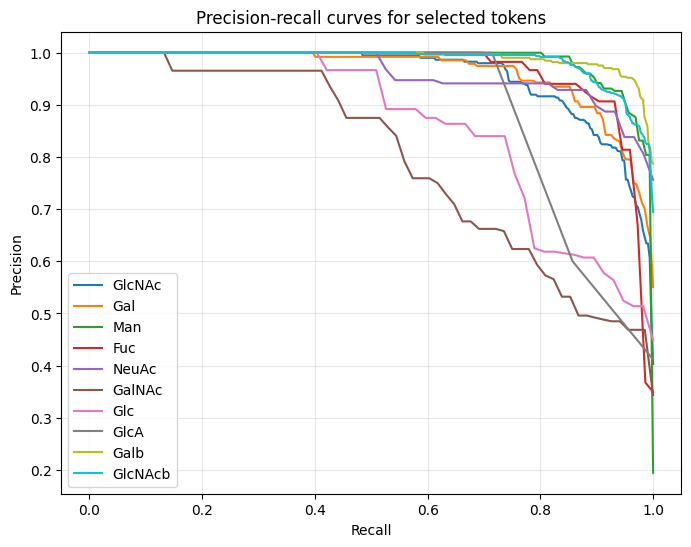

,token,average_precision
0,GlcNAc,0.955560
1,Gal,0.961757
2,Man,0.982412
3,Fuc,0.960347
4,NeuAc,0.957758
5,GalNAc,0.785497
6,Glc,0.858308
7,GlcA,0.858824
8,Galb,0.990167
9,GlcNAcb,0.984716


PR plot saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/pr_curves.png
PR summary saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/pr_auc_summary.csv


In [13]:
# ==============================================================================
# 13. PRECISION-RECALL CURVES FOR TOKENIZER-SPECIFIC TOKENS
# ==============================================================================
pr_summary = plot_pr_for_selected_classes(
    y_true=y_true,
    y_probs=y_probs,
    tokenizer=tokenizer,
    selected_tokens=selected_tokens,
    save_path=PR_PLOT_PATH,
)

display(pr_summary)
pr_summary.to_csv(PR_SUMMARY_PATH, index=False)

print(f'PR plot saved to: {PR_PLOT_PATH}')
print(f'PR summary saved to: {PR_SUMMARY_PATH}')




## Qualitative biological probes

This is where I check whether the model is recovering biologically meaningful pieces in context, not just doing okay on aggregate metrics. The probes use the same glycan concepts across tokenizers, but the masked target is tokenizer-specific.

That tokenizer-specific part matters a lot here. I don't think it would make sense to force the exact same mask position if the tokenizers carved up the sequence differently. What I want to compare is whether each model seems able to recover the same underlying biological idea, even if that means predicting a whole linkage block, a donor-bound unit, or a smaller semi-atomic residue token.

This is probably still one of the more provisional parts of the evaluation, but it feels important because the end goal is not just masked-token accuracy by itself. The real question is whether the embeddings are starting to capture glycan semantics in a meaningful way.



In [14]:
# ==============================================================================
# 14. QUALITATIVE PROBES
# ==============================================================================
probe_cases = get_core_probe_cases()

qualitative_probe_results = run_structured_qualitative_probe(
    model=model,
    tokenizer=tokenizer,
    tokenizer_family=TOKENIZER_FAMILY,
    probe_cases=probe_cases,
    device=device,
)

display(qualitative_probe_results)
qualitative_probe_results.to_csv(QUALITATIVE_PROBE_PATH, index=False)

print(f'Qualitative probe results saved to: {QUALITATIVE_PROBE_PATH}')




,probe_id,concept,base_sequence,biological_target,masked_sequence,expected_token,target_token_type,rank,predicted_token,score,is_expected
0,glcnac_core,GlcNAc in an N-glycan core context,Galb1-4GlcNAcb1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,Galb1-4<mask>b1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,byte_bpe_residue,1,Xyl,0.812366,False
1,glcnac_core,GlcNAc in an N-glycan core context,Galb1-4GlcNAcb1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,Galb1-4<mask>b1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,byte_bpe_residue,2,)(,0.088718,False
2,glcnac_core,GlcNAc in an N-glycan core context,Galb1-4GlcNAcb1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,Galb1-4<mask>b1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,byte_bpe_residue,3,GlcA,0.057559,False
3,glcnac_core,GlcNAc in an N-glycan core context,Galb1-4GlcNAcb1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,Galb1-4<mask>b1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,byte_bpe_residue,4,GlcNAc,0.010521,True
4,glcnac_core,GlcNAc in an N-glycan core context,Galb1-4GlcNAcb1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,Galb1-4<mask>b1-2Mana1-3Manb1-4GlcNAcb1-4GlcNAc,GlcNAc,byte_bpe_residue,5,Fuc,0.009900,False
5,gal_terminal,Terminal Gal in antenna context,NeuAca2-3Galb1-4GlcNAcb1-2Mana1-3(Galb1-4GlcNA...,Gal,NeuAca2-3<mask>b1-4GlcNAcb1-2Mana1-3(Galb1-4Gl...,Gal,byte_bpe_residue,1,Xyl,0.426661,False
6,gal_terminal,Terminal Gal in antenna context,NeuAca2-3Galb1-4GlcNAcb1-2Mana1-3(Galb1-4GlcNA...,Gal,NeuAca2-3<mask>b1-4GlcNAcb1-2Mana1-3(Galb1-4Gl...,Gal,byte_bpe_residue,2,Gal,0.346106,True
7,gal_terminal,Terminal Gal in antenna context,NeuAca2-3Galb1-4GlcNAcb1-2Mana1-3(Galb1-4GlcNA...,Gal,NeuAca2-3<mask>b1-4GlcNAcb1-2Mana1-3(Galb1-4Gl...,Gal,byte_bpe_residue,3,GlcA,0.074543,False
8,gal_terminal,Terminal Gal in antenna context,NeuAca2-3Galb1-4GlcNAcb1-2Mana1-3(Galb1-4GlcNA...,Gal,NeuAca2-3<mask>b1-4GlcNAcb1-2Mana1-3(Galb1-4Gl...,Gal,byte_bpe_residue,4,GlcNAc,0.050871,False
9,gal_terminal,Terminal Gal in antenna context,NeuAca2-3Galb1-4GlcNAcb1-2Mana1-3(Galb1-4GlcNA...,Gal,NeuAca2-3<mask>b1-4GlcNAcb1-2Mana1-3(Galb1-4Gl...,Gal,byte_bpe_residue,5,Fuc,0.032619,False


Qualitative probe results saved to: /content/drive/MyDrive/ProjectRoot/results/test_evaluation/byte_bpe/mlm15_L6_H512_A8_lr00001_ep100_setv300_m2_cont_lr5e-05_ep20/qualitative_probe_results.csv


## Record the result in the run index

I want the run index to point to the saved test outputs so I can trace everything later without guessing which folder went with which run. If the evaluation setup changes a little over time, having this index should make it easier to keep track of what was actually run and what files went with that version of the workflow.



In [15]:
# ==============================================================================
# 15. UPDATE RUN INDEX
# ==============================================================================
upsert_run_record(
    RUN_INDEX_PATH,
    {
        'experiment_name': EXPERIMENT_NAME,
        'tokenizer_family': TOKENIZER_FAMILY,
        'setting_label': SETTING_LABEL,
        'results_dir': RESULTS_DIR,
        'test_metrics_path': TEST_SUMMARY_JSON_PATH,
        'qualitative_probe_path': QUALITATIVE_PROBE_PATH,
        'notebook_used': 'notebooks/06_test_set_evaluation.ipynb',
        'run_status': 'tested',
        'notes': '',
    },
)

print(f'Run index updated: {RUN_INDEX_PATH}')




Run index updated: /content/drive/MyDrive/ProjectRoot/registry/run_index.csv
